
11490434/11490434 [==============================] - 6s 0us/step


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                      

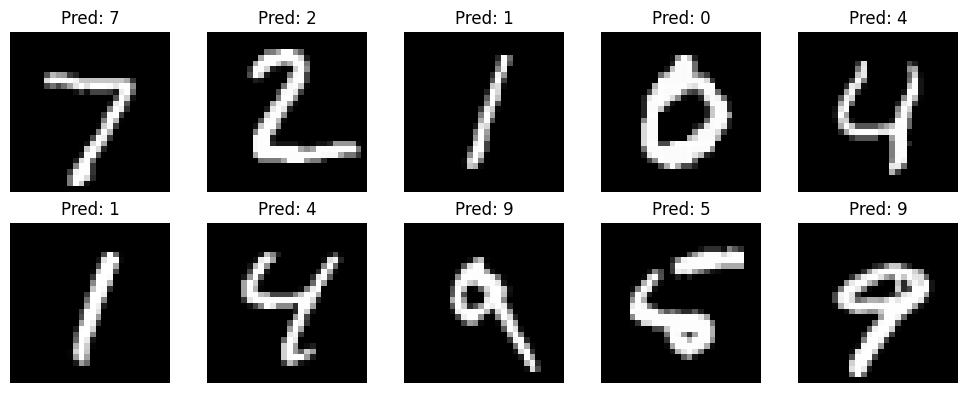

In [1]:
# 1️⃣ Import Required Libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 2️⃣ Load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 3️⃣ Preprocess the Dataset

# Reshape to (28, 28, 1) for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 4️⃣ Build CNN Model
model = keras.Sequential([
    
    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Flatten Layer
    layers.Flatten(),
    
    # Dense Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer (10 Classes)
    layers.Dense(10, activation='softmax')
])

# Show model summary
model.summary()

# 5️⃣ Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6️⃣ Train the Model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# 7️⃣ Evaluate the Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# 8️⃣ Predict Some Test Images
predictions = model.predict(x_test)

# Display first 10 predictions
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Pred: {}".format(np.argmax(predictions[i])))
    plt.axis('off')

plt.tight_layout()
plt.show()


170498071/170498071 [==============================] - 61s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 4, 4, 128)         73856     
                                                    

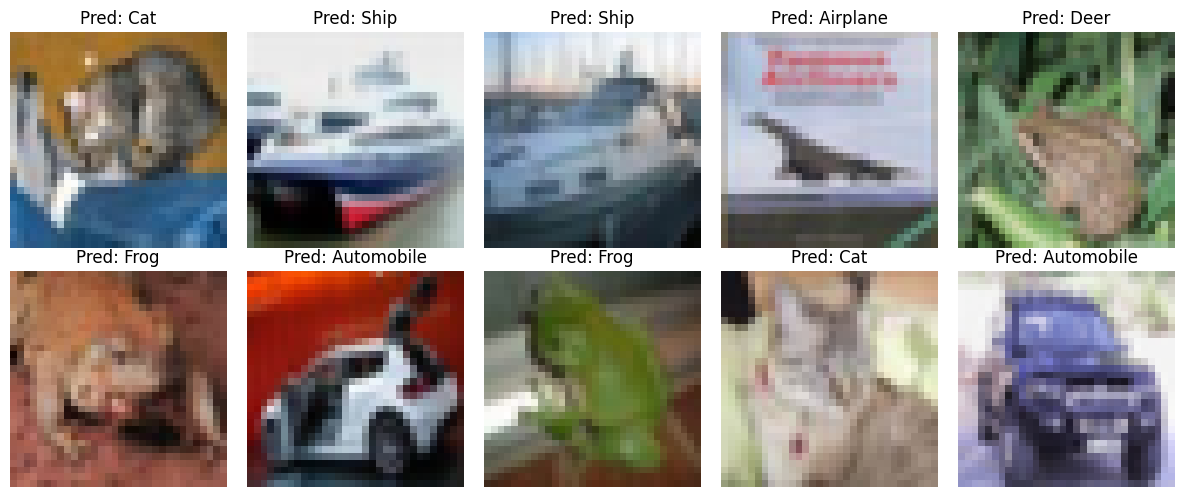

In [2]:
# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ==============================
# 2️⃣ Load CIFAR-10 Dataset
# ==============================

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# ==============================
# 3️⃣ Preprocess Data
# ==============================

# Normalize pixel values (0-255 → 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ==============================
# 4️⃣ Build CNN Model
# ==============================

model = keras.Sequential([

    # First Convolution Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Second Convolution Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output Layer (10 classes)
    layers.Dense(10, activation='softmax')
])

# Show Model Summary
model.summary()

# ==============================
# 5️⃣ Compile Model
# ==============================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 6️⃣ Train Model
# ==============================

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

# ==============================
# 7️⃣ Evaluate Model
# ==============================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# ==============================
# 8️⃣ Make Predictions
# ==============================

predictions = model.predict(x_test)

# CIFAR-10 Class Names
class_names = [
    'Airplane','Automobile','Bird','Cat','Deer',
    'Dog','Frog','Horse','Ship','Truck'
]

# Display First 10 Predictions
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title("Pred: {}".format(class_names[np.argmax(predictions[i])]))
    plt.axis('off')

plt.tight_layout()
plt.show()
